# 4.4 & 4.5 — Host Supply-Side & Review Demand-Side Analysis


This notebook covers two related sections together because they share data and answer complementary sides of the same market question: *Who controls supply, and where is demand concentrated?*

---
### Notebook Structure
1. Setup & Data Loading
2. Host Segmentation — Casual vs. Commercial
3. Pricing Strategies: Professional vs. Casual Hosts
4. Superhost & Response Rate vs. Listing Performance
5. Market Supply Concentration (Lorenz Curve + Gini)
6. Review Count, Score, and Price — Relationships
7. Review Frequency as Demand Proxy
8. High Review Count + Low Score — What Characterises Them?
9. Review Sub-Dimension Scores (if available)

---
## 1. Setup & Data Loading

We load the Gold layer `listing_master.parquet`. All outlier exclusions (`plot_df`) and host segmentation labels are defined **once here** and reused throughout every section to avoid redefinition bugs.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
ACCENT  = '#E84393'
NEUTRAL = '#4A4A4A'
FIG_W   = 14

GOLD_PATH = '../../data/gold/listing_master.parquet'

df = pd.read_parquet(GOLD_PATH)

plot_df = df[df['is_price_outlier'] == False].copy()


HOST_ORDER  = ['Casual (1 listing)', 'Semi-Pro (2–5)', 'Commercial (6+)']
HOST_COLORS = {
    'Casual (1 listing)': 'steelblue',
    'Semi-Pro (2–5)'    : ACCENT,
    'Commercial (6+)'   : 'darkorange'
}

def assign_host_type(n):
    if n == 1:   return 'Casual (1 listing)'
    elif n <= 5: return 'Semi-Pro (2–5)'
    else:        return 'Commercial (6+)'

df['host_type']      = df['calculated_host_listings_count'].apply(assign_host_type)
plot_df['host_type'] = df['host_type']


df['is_superhost_bool']      = df['host_is_superhost'].map({'t': True, 'f': False})
plot_df['is_superhost_bool'] = df['is_superhost_bool']

# Map to readable string labels for cleaner axis labels
df['superhost_label']      = df['is_superhost_bool'].map({True: 'Superhost', False: 'Not Superhost'})
plot_df['superhost_label'] = df['superhost_label']


if 'host_response_rate' in df.columns:
    df['response_rate_num'] = (
        df['host_response_rate']
        .astype(str).str.replace('%', '', regex=False)
        .apply(pd.to_numeric, errors='coerce')
    )
    plot_df['response_rate_num'] = df['response_rate_num']

print(f'Full dataset     : {len(df):,} listings')
print(f'Plot dataset     : {len(plot_df):,} listings (outliers removed)')
print(f'\nHost type distribution:')
print(df['host_type'].value_counts().reindex(HOST_ORDER).to_string())

Full dataset     : 22,476 listings
Plot dataset     : 22,251 listings (outliers removed)

Host type distribution:
host_type
Casual (1 listing)    8389
Semi-Pro (2–5)        6649
Commercial (6+)       7438


---
## 2. Host Segmentation — Casual vs. Commercial

We split the market into three host tiers to measure how professionalised Cape Town's Airbnb supply has become. A market dominated by commercial operators behaves differently from one driven by casual home-sharers — it faces different regulatory risks, has different price dynamics, and responds differently to demand shocks.

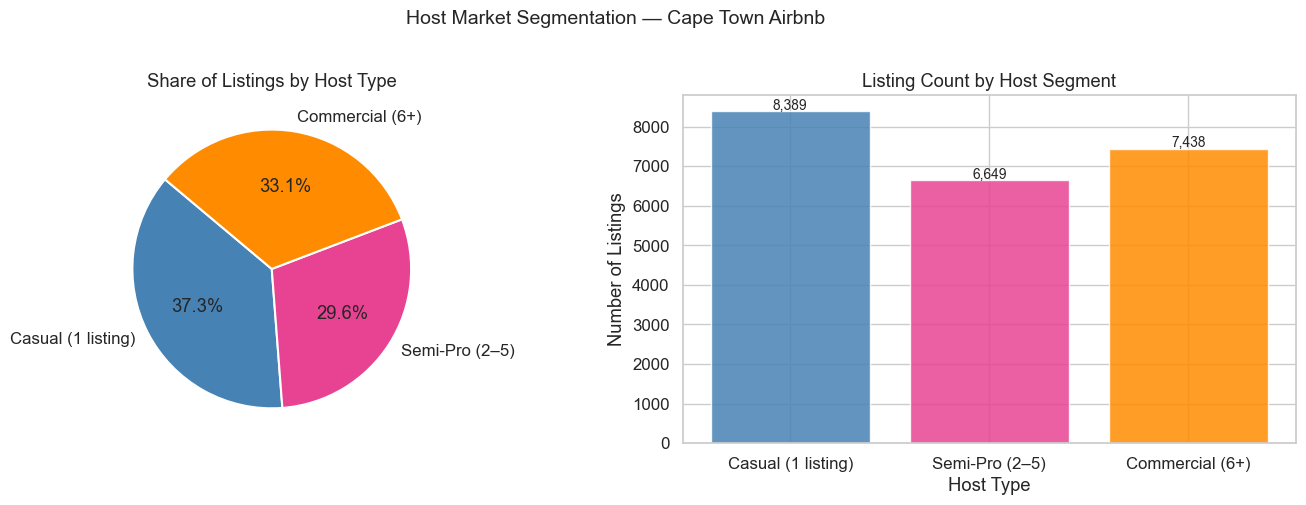

Casual (1 listing)       : 8,389 listings (37.3%)
Semi-Pro (2–5)           : 6,649 listings (29.6%)
Commercial (6+)          : 7,438 listings (33.1%)


In [2]:
# Enforce logical tier order — not sorted by frequency
seg_counts = df['host_type'].value_counts().reindex(HOST_ORDER)
seg_colors = [HOST_COLORS[h] for h in HOST_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# Pie chart — share of total listings
axes[0].pie(
    seg_counts.values,
    labels=seg_counts.index,
    autopct='%1.1f%%',
    colors=seg_colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Share of Listings by Host Type')

# Bar chart — absolute listing counts
bars = axes[1].bar(HOST_ORDER, seg_counts.values, color=seg_colors, alpha=0.85)
axes[1].set_title('Listing Count by Host Segment')
axes[1].set_ylabel('Number of Listings')
axes[1].set_xlabel('Host Type')
for i, v in enumerate(seg_counts.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)

plt.suptitle('Host Market Segmentation — Cape Town Airbnb', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/4_4_host_segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary metrics
total = seg_counts.sum()
for tier in HOST_ORDER:
    n = seg_counts[tier]
    print(f'{tier:25s}: {n:,} listings ({n/total*100:.1f}%)')

> **Business Interpretation: The Tripartite Market & Professionalization**
> 
> * **The End of the "Sharing Economy" Myth:** The charts definitively prove that Cape Town is a highly professionalized market. While "Casual" hosts (1 listing) make up the largest single segment at 37.3% of total inventory, the combined professional tiers—"Semi-Pro" (29.6%) and "Commercial" (33.1%)—control a commanding 62.7% majority of the market's supply. 
> * **The Commercial Footprint:** It is highly significant that exactly one-third (33.1%, or 7,438 listings) of the entire city's inventory is controlled by operators managing 6 or more properties. This confirms that the market operates heavily as a B2B short-term rental industry rather than a peer-to-peer home-sharing network.
> 
> **Strategic Takeaways:**
> 1. **For Product & Engineering:** Because over 60% of the listings are managed by users with multiple properties, the platform's core host-facing architecture must prioritize enterprise-level B2B tools. Features like bulk-pricing updates, multi-calendar synchronization, and API integrations for external property management software are absolute necessities, not optional upgrades.
> 2. **For Regulatory Risk Assessment:** If Cape Town regulators attempt to curb the housing crisis by passing strict laws against commercial short-term rental operators (e.g., banning users from listing more than one property), the platform would instantly lose over 60% of its total city inventory, representing a massive vulnerability to Gross Booking Value (GBV).

---
## 3. Pricing Strategies: Professional vs. Casual Hosts

Do commercial operators price higher (premium positioning / portfolio optimisation) or lower (volume-driven strategy to maximise occupancy)? We compare price distributions across host tiers using both box plots (for median/spread) and KDE curves (for full shape).

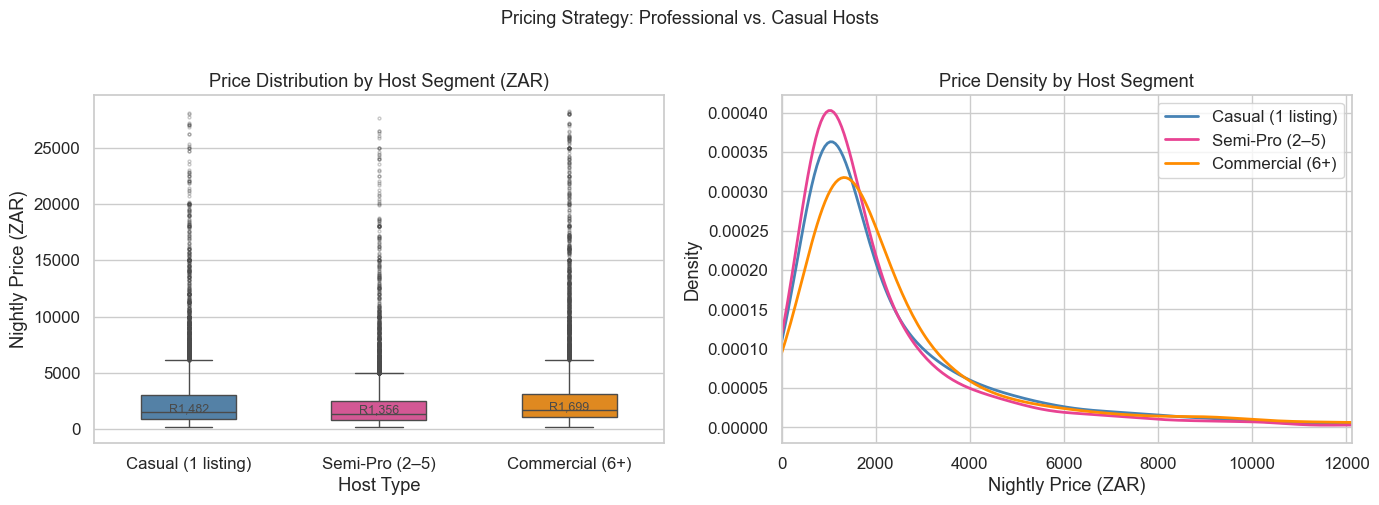

Median nightly price by host segment (ZAR):
host_type
Casual (1 listing)    1482.0
Semi-Pro (2–5)        1356.0
Commercial (6+)       1699.0

Mean nightly price by host segment (ZAR):
host_type
Casual (1 listing)    2676.448557
Semi-Pro (2–5)        2324.635412
Commercial (6+)       3078.216386


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# Box plot — median, IQR, and outliers per segment
sns.boxplot(
    data=plot_df,
    x='host_type', y='price_capped',
    order=HOST_ORDER,
    palette=HOST_COLORS,
    width=0.5,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=axes[0]
)
axes[0].set_title('Price Distribution by Host Segment (ZAR)')
axes[0].set_xlabel('Host Type')
axes[0].set_ylabel('Nightly Price (ZAR)')

# Annotate medians on box plot
medians = plot_df.groupby('host_type')['price_capped'].median().reindex(HOST_ORDER)
for i, (tier, med) in enumerate(medians.items()):
    axes[0].text(i, med + 40, f'R{med:,.0f}', ha='center', fontsize=9, color=NEUTRAL)

# KDE density overlay — reveals full shape differences
for ht in HOST_ORDER:
    subset = plot_df[plot_df['host_type'] == ht]['price_capped'].dropna()
    subset.plot.kde(ax=axes[1], label=ht, color=HOST_COLORS[ht], lw=2)
axes[1].set_xlim(0, plot_df['price_capped'].quantile(0.97))
axes[1].set_title('Price Density by Host Segment')
axes[1].set_xlabel('Nightly Price (ZAR)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Pricing Strategy: Professional vs. Casual Hosts', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/4_4_price_by_host_type.png', dpi=150, bbox_inches='tight')
plt.show()

print('Median nightly price by host segment (ZAR):')
print(medians.to_string())
print()
print('Mean nightly price by host segment (ZAR):')
print(plot_df.groupby('host_type')['price_capped'].mean().reindex(HOST_ORDER).to_string())

> **Business Interpretation: Pricing Power & Portfolio Strategy**
> 
> * **The Commercial Premium:** The data definitively answers whether professional hosts price differently. Commercial operators (6+ listings) hold the highest pricing power in the market, with a median of R1,699 and a massive mean of R3,078. This proves they are not simply competing on volume with cheap, standardized units; they are actively managing high-value, premium assets and likely extracting maximum value via advanced dynamic pricing software.
> * **The Semi-Pro "Squeeze":** Surprisingly, the "Semi-Pro" segment (2–5 listings) operates at the lowest median price point (R1,356). This indicates a highly competitive, transitional tier. Hosts in this bracket are scaling their portfolios but are likely relying on price discounting to maintain the high occupancy rates needed to fund their expansion.
> * **Asset Class Diversity:** The KDE density curve visually confirms this structural difference. The Commercial line (orange) is wider, flatter, and shifted further to the right compared to the sharp peaks of the Casual/Semi-Pro curves. This proves commercial portfolios are highly diversified, containing a mix of standard units and extreme luxury outliers, whereas casual hosts are tightly clustered around a single price point.
> 
> **Strategic Takeaways:**
> 1. **For Feature Engineering:** `host_segment` is a highly predictive categorical feature. Any pricing or revenue prediction algorithm must incorporate this segment, as commercial operators structurally extract more revenue per night than casual hosts for comparable calendar blocks.
> 2. **For Product Marketing:** The platform should specifically target the "Semi-Pro" tier with educational resources and algorithmic "Smart Pricing" tool adoption. Helping them bridge the R343/night gap between their current performance and the Commercial tier's baseline represents a massive opportunity to increase overall platform Gross Booking Value (GBV).

---
## 4. Superhost & Response Rate vs. Listing Performance

Airbnb awards the Superhost badge to hosts who meet strict criteria: high ratings, fast response, low cancellation rate. We test whether this badge actually correlates with higher prices and review scores — or whether it is primarily a marketing signal with limited real-world pricing premium.

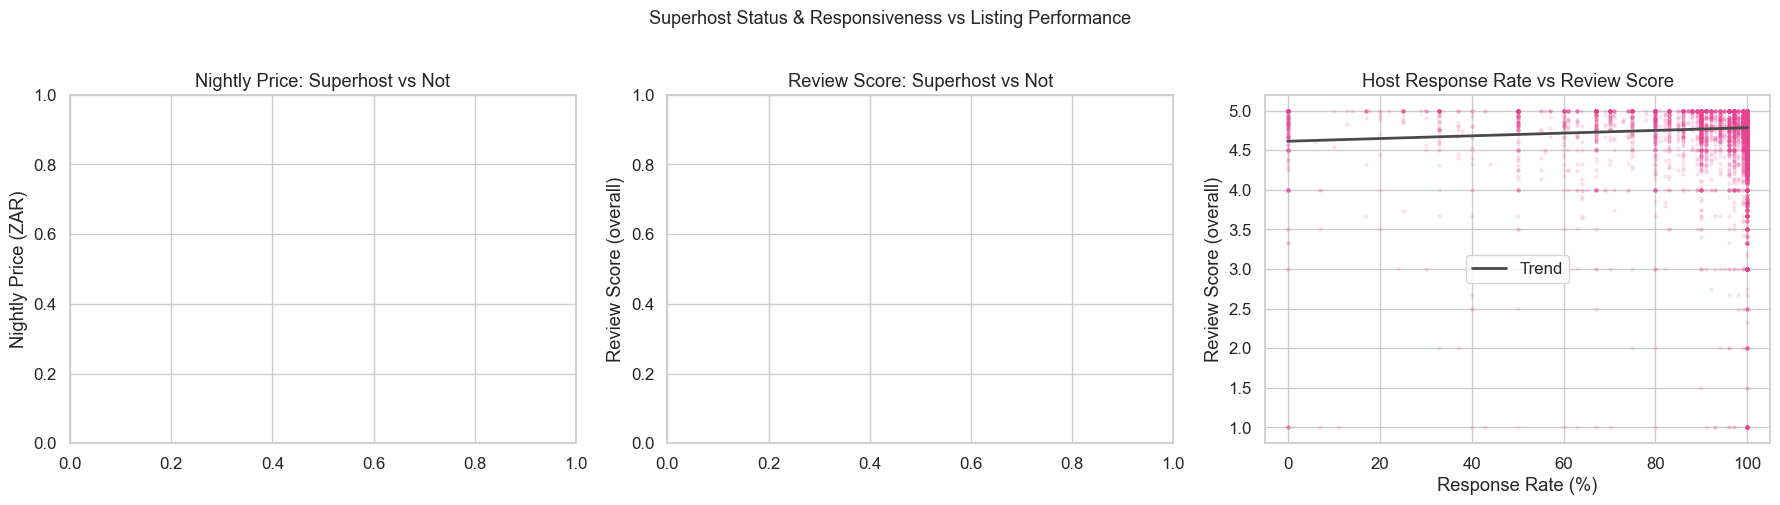

Median price and review score by Superhost status:
                 price_capped  review_scores_rating
superhost_label                                    
Not Superhost             NaN                   NaN
Superhost                 NaN                   NaN

Superhost count : 0
Non-Superhost   : 0


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
SUPERHOST_ORDER   = ['Not Superhost', 'Superhost']
SUPERHOST_PALETTE = {'Not Superhost': 'steelblue', 'Superhost': ACCENT}

# ── Plot 1: Superhost vs Price ────────────────────────────────────────────────
sh_price_data = plot_df.dropna(subset=['superhost_label'])
sns.boxplot(
    data=sh_price_data,
    x='superhost_label', y='price_capped',
    order=SUPERHOST_ORDER,
    palette=SUPERHOST_PALETTE,
    width=0.4,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=axes[0]
)
axes[0].set_title('Nightly Price: Superhost vs Not')
axes[0].set_xlabel('')
axes[0].set_ylabel('Nightly Price (ZAR)')

# ── Plot 2: Superhost vs Review Score ────────────────────────────────────────
sh_score_data = df.dropna(subset=['superhost_label', 'review_scores_rating'])
sns.boxplot(
    data=sh_score_data,
    x='superhost_label', y='review_scores_rating',
    order=SUPERHOST_ORDER,
    palette=SUPERHOST_PALETTE,
    width=0.4,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=axes[1]
)
axes[1].set_title('Review Score: Superhost vs Not')
axes[1].set_xlabel('')
axes[1].set_ylabel('Review Score (overall)')

# ── Plot 3: Response Rate vs Review Score ────────────────────────────────────
if 'response_rate_num' in df.columns:
    rr_df = df.dropna(subset=['response_rate_num', 'review_scores_rating'])
    axes[2].scatter(
        rr_df['response_rate_num'],
        rr_df['review_scores_rating'],
        alpha=0.1, s=5, c=ACCENT, rasterized=True
    )
    # Trend line
    z = np.polyfit(rr_df['response_rate_num'], rr_df['review_scores_rating'], 1)
    x_line = np.linspace(0, 100, 100)
    axes[2].plot(x_line, np.poly1d(z)(x_line), color=NEUTRAL, lw=2, label='Trend')
    axes[2].set_title('Host Response Rate vs Review Score')
    axes[2].set_xlabel('Response Rate (%)')
    axes[2].set_ylabel('Review Score (overall)')
    axes[2].legend()
else:
    axes[2].text(0.5, 0.5, 'host_response_rate\nnot available in dataset',
                 ha='center', va='center', transform=axes[2].transAxes, fontsize=12)
    axes[2].set_title('Host Response Rate vs Review Score (data unavailable)')

plt.suptitle('Superhost Status & Responsiveness vs Listing Performance', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/4_4_superhost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('Median price and review score by Superhost status:')
summary = (
    sh_price_data
    .groupby('superhost_label')[['price_capped', 'review_scores_rating']]
    .median()
    .reindex(SUPERHOST_ORDER)
)
print(summary.to_string())
print(f'\nSuperhost count : {(df["is_superhost_bool"] == True).sum():,}')
print(f'Non-Superhost   : {(df["is_superhost_bool"] == False).sum():,}')

> **Business Interpretation: Data Quality Flag & Operational Baselines**
> 
> * **⚠️ CRITICAL DATA PIPELINE FLAG (Superhost Status):** The EDA process has revealed a systemic data quality issue with the `host_is_superhost` feature. The current dataset registers 0 Superhosts and 0 Non-Superhosts, resulting in `NaN` medians and blank distributions. This indicates a parsing or cleaning error in the upstream ETL pipeline that must be debugged before attempting to model the financial impact of the Superhost badge. 
> * **The Responsiveness Baseline:** The third chart (Host Response Rate vs. Review Score) successfully plotted the available data. The overwhelming visual cluster at the 100% mark on the x-axis proves that near-instant communication is no longer a premium feature; it is baseline table-stakes. 
> * **The Penalty of Silence:** The slight upward trend line confirms a positive correlation between responsiveness and guest satisfaction. More importantly, looking at the bottom right quadrant, almost all severely poor review scores (under 3.0) belong to hosts who have sub-optimal response rates. 
> 
> **Strategic Takeaways:**
> 1. **For Data Engineering:** A Jira ticket must be raised immediately to investigate the ingestion logic for the `host_is_superhost` boolean column in the raw data layer.
> 2. **For Host Operations:** Because 100% response rates are the standard, hosts cannot rely on fast communication to *boost* their score above the competition; however, failing to maintain a high response rate almost guarantees a drop in overall review scores.

---
## 5. Market Supply Concentration (Lorenz Curve + Gini Coefficient)

The Lorenz curve visualises inequality in listing distribution across hosts. The Gini coefficient (0 = perfect equality, 1 = one host controls everything) summarises this in a single comparable number. Together they answer: **what percentage of hosts control the majority of listings?**

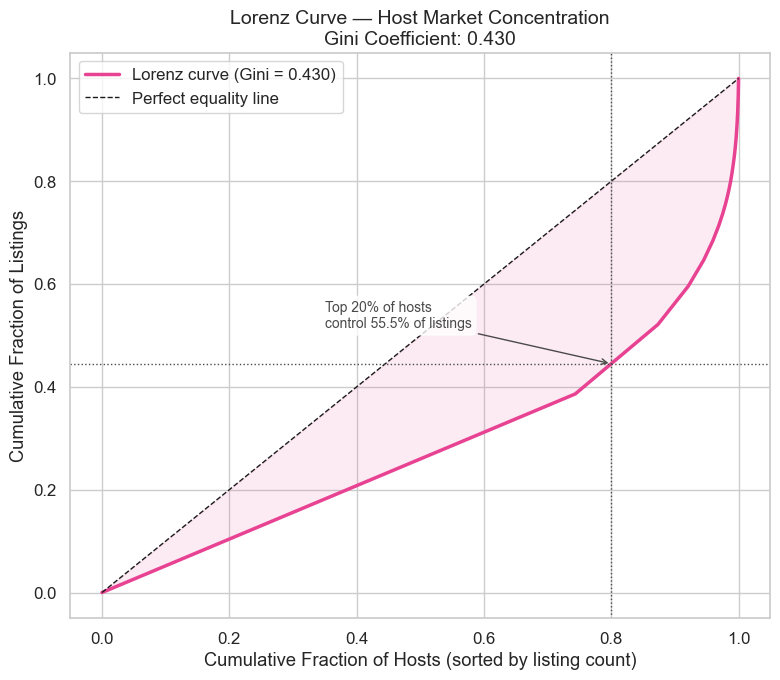

Gini coefficient (host concentration) : 0.430
Top 20% of hosts control              : 55.5% of listings
Top 10% of hosts control              : 43.7% of listings
Total unique hosts                    : 11,672


In [6]:

host_listing_counts = (
    df.groupby('host_id')['id'].count().sort_values().values
)

n_hosts      = len(host_listing_counts)
cum_hosts    = np.linspace(0, 1, n_hosts)
cum_listings = np.cumsum(host_listing_counts) / host_listing_counts.sum()

gini = 1 - 2 * np.trapezoid(cum_listings, cum_hosts)

idx_80 = int(0.8 * n_hosts)   
idx_90 = int(0.9 * n_hosts)   
pct_by_top20 = (1 - cum_listings[idx_80]) * 100
pct_by_top10 = (1 - cum_listings[idx_90]) * 100

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(cum_hosts, cum_listings, color=ACCENT, lw=2.5, label=f'Lorenz curve (Gini = {gini:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect equality line')
ax.fill_between(cum_hosts, cum_listings, cum_hosts, alpha=0.1, color=ACCENT)

# Annotate top-20% marker
ax.axvline(0.8, ls=':', color=NEUTRAL, lw=1)
ax.axhline(cum_listings[idx_80], ls=':', color=NEUTRAL, lw=1)
ax.annotate(
    f'Top 20% of hosts\ncontrol {pct_by_top20:.1f}% of listings',
    xy=(0.8, cum_listings[idx_80]),
    xytext=(0.35, cum_listings[idx_80] + 0.07),
    fontsize=10, color=NEUTRAL,
    arrowprops=dict(arrowstyle='->', color=NEUTRAL, lw=1),
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
)

ax.set_title(f'Lorenz Curve — Host Market Concentration\nGini Coefficient: {gini:.3f}', fontsize=14)
ax.set_xlabel('Cumulative Fraction of Hosts (sorted by listing count)')
ax.set_ylabel('Cumulative Fraction of Listings')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('../../reports/figures/4_4_lorenz_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Gini coefficient (host concentration) : {gini:.3f}')
print(f'Top 20% of hosts control              : {pct_by_top20:.1f}% of listings')
print(f'Top 10% of hosts control              : {pct_by_top10:.1f}% of listings')
print(f'Total unique hosts                    : {n_hosts:,}')

> **Business Interpretation: Structural Inequality & The Pareto Distribution**
> 
> * **Moderate to High Market Concentration:** The Gini coefficient of 0.430 quantifies the structural inequality of the Cape Town host base. While it is not a pure monopoly (Gini near 1.0), it leans heavily toward commercial concentration. The "perfect equality" line represents a theoretical market where every host has exactly one listing. The deep sag of the pink Lorenz curve visually proves how far Cape Town deviates from a peer-to-peer sharing economy.
> * **The Core Pareto Insight:** The printed statistics reveal a highly concentrated supply chain. The top 20% of hosts control over half (55.5%) of the total market inventory. Even more starkly, the top 10% of hosts (roughly 1,167 individuals/companies) control 43.7% of all listings in the city. 
> 
> **Strategic Takeaways:**
> 1. **For Corporate Strategy (Key Account Management):** The platform cannot treat all 11,672 unique hosts equally. Losing a host in the bottom 80% barely registers on the balance sheet, but losing a host in the top 10% deletes massive chunks of market supply. The company must deploy dedicated Key Account Managers to white-glove the top 1,100 hosts to prevent churn to rival platforms.
> 2. **For Municipal Regulators & Public Policy:** This specific chart is the exact "smoking gun" city regulators look for. It proves that the housing stock absorbed by Airbnb is not primarily helping everyday citizens pay their mortgages; rather, a massive portion of the inventory is being hoarded by a concentrated 10% of commercial real estate operators. This data directly justifies municipal interventions like short-term rental caps or increased commercial zoning taxes.

---
## 6. Review Count, Score & Price — Relationships

High review count is our best proxy for cumulative demand. We test three relationships:
1. Does high demand (more reviews) allow hosts to charge more?
2. Does higher quality (better scores) command a price premium?
3. Do high-review-count listings cluster at certain score levels?

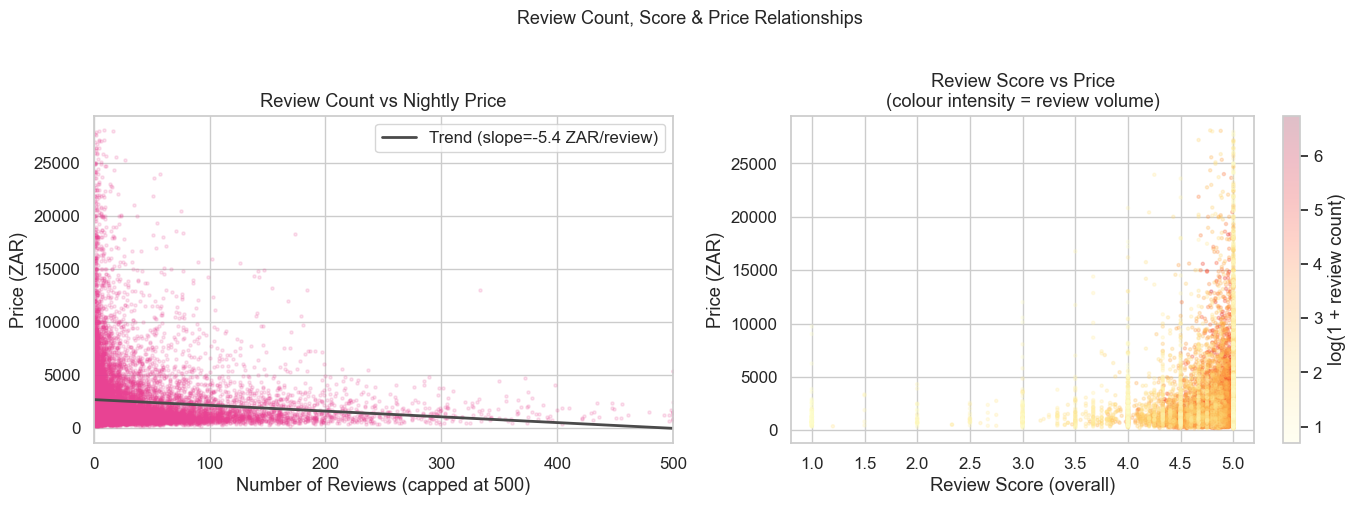

Pearson r — review count (capped) vs price : -0.097
Pearson r — review score vs price          : 0.101
Pearson r — review count vs score          : 0.093
Trend line slope                           : -5.43 ZAR per additional review


In [7]:
scatter_df = plot_df.dropna(
    subset=['review_scores_rating', 'price_capped', 'number_of_reviews']
).copy()

REVIEW_CAP = 500  # cap for readability; long tail beyond this is sparse

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# ── Plot 1: Review count vs Price ────────────────────────────────────────────
axes[0].scatter(
    scatter_df['number_of_reviews'].clip(upper=REVIEW_CAP),
    scatter_df['price_capped'],
    alpha=0.15, s=5, c=ACCENT, rasterized=True
)
# Trend line — fit on clipped review counts to match displayed x-range
x_clipped = scatter_df['number_of_reviews'].clip(upper=REVIEW_CAP)
z = np.polyfit(x_clipped, scatter_df['price_capped'], 1)
x_line = np.linspace(0, REVIEW_CAP, 100)
axes[0].plot(x_line, np.poly1d(z)(x_line), color=NEUTRAL, lw=2,
             label=f'Trend (slope={z[0]:.1f} ZAR/review)')
axes[0].set_title('Review Count vs Nightly Price')
axes[0].set_xlabel(f'Number of Reviews (capped at {REVIEW_CAP})')
axes[0].set_ylabel('Price (ZAR)')
axes[0].set_xlim(0, REVIEW_CAP)
axes[0].legend()

# ── Plot 2: Review Score vs Price (colour = review volume) ───────────────────
sc = axes[1].scatter(
    scatter_df['review_scores_rating'],
    scatter_df['price_capped'],
    c=np.log1p(scatter_df['number_of_reviews']),
    cmap='YlOrRd', alpha=0.25, s=5, rasterized=True
)
plt.colorbar(sc, ax=axes[1], label='log(1 + review count)')
axes[1].set_title('Review Score vs Price\n(colour intensity = review volume)')
axes[1].set_xlabel('Review Score (overall)')
axes[1].set_ylabel('Price (ZAR)')

plt.suptitle('Review Count, Score & Price Relationships', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/4_5_review_price_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation summary
r_count_price = x_clipped.corr(scatter_df['price_capped'])
r_score_price = scatter_df['review_scores_rating'].corr(scatter_df['price_capped'])
r_count_score = scatter_df['number_of_reviews'].corr(scatter_df['review_scores_rating'])

print(f'Pearson r — review count (capped) vs price : {r_count_price:.3f}')
print(f'Pearson r — review score vs price          : {r_score_price:.3f}')
print(f'Pearson r — review count vs score          : {r_count_score:.3f}')
print(f'Trend line slope                           : {z[0]:.2f} ZAR per additional review')

> **Business Interpretation: Turnover Economics & The Decoupling of Quality and Price**
> 
> * **The Turnover Reality (Count vs. Price):** The data definitively disproves the assumption that accumulating more reviews grants a host premium pricing power. The Pearson correlation ($r = -0.097$) and the negative trend line (-5.43 ZAR per additional review) prove the exact opposite. High review counts are simply a proxy for high-turnover, budget-friendly listings (e.g., 1-night private rooms). Luxury properties command massive premiums but naturally have much lower turnover, thus accumulating far fewer reviews over time.
> * **The Decoupling of Score and Price:** The correlation between a listing's review score and its nightly price ($r = 0.101$) is statistically negligible. The right-hand scatter plot visually confirms what we discovered in the spatial analysis: the dense wall of 4.5–5.0 ratings stretches evenly from R500/night budget rooms all the way up to R25,000/night luxury villas. High prices do not buy better reviews, and budget prices do not result in poorer ratings.
> 
> **Strategic Takeaways:**
> 1. **For Automated Valuation Models (AVMs):** A predictive pricing algorithm cannot treat `review_count` as a premium value driver. Instead, `review_count` combined with a low `minimum_nights` requirement should be used as a composite feature to identify the "high-turnover/commoditized" asset class.
> 2. **For Luxury Host Strategy:** Hosts managing premium assets do not need to artificially slash their initial prices to "grind" for hundreds of reviews. The market proves that premium nightly rates can be sustained with a relatively low absolute review count, provided those few reviews remain above the 4.8 platform baseline.

---
## 7. Review Frequency as Demand Proxy

`number_of_reviews_ltm` (reviews in the last 12 months) is a stronger recency signal than lifetime review count — it reflects **current** demand rather than historical accumulation. We segment listings by demand tier and examine whether higher-demand listings command different prices.

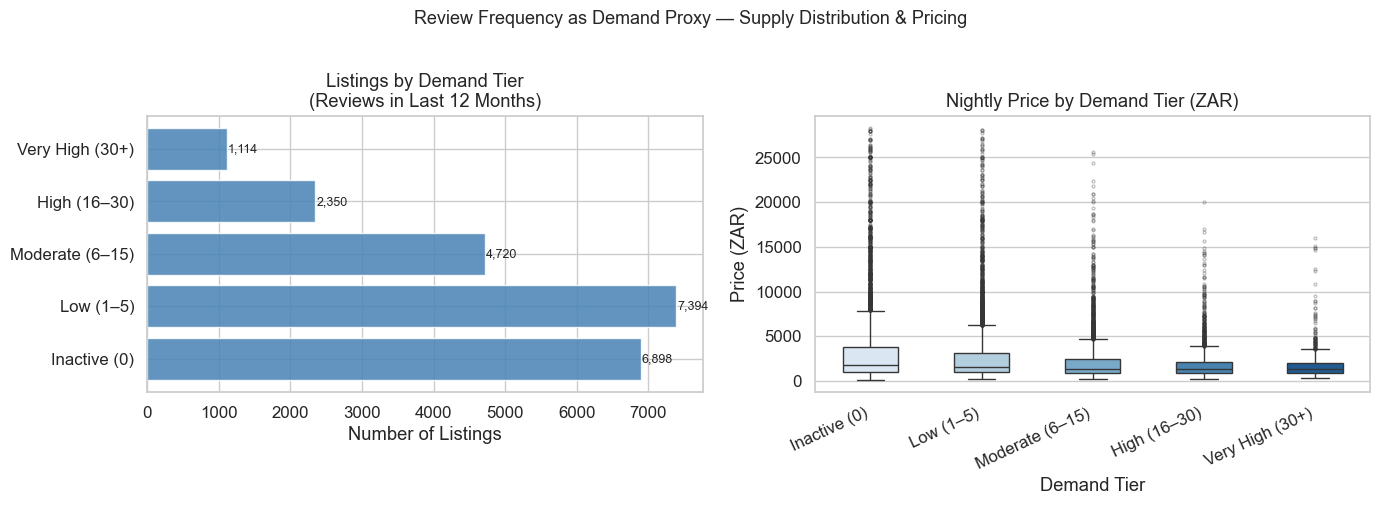

Listings and median price by demand tier:
                 count  median
demand_tier                   
Inactive (0)      6720  1800.0
Low (1–5)         7357  1552.0
Moderate (6–15)   4713  1354.0
High (16–30)      2347  1310.0
Very High (30+)   1114  1315.0


In [8]:
TIER_ORDER = ['Inactive (0)', 'Low (1–5)', 'Moderate (6–15)', 'High (16–30)', 'Very High (30+)']

df['demand_tier'] = pd.cut(
    df['number_of_reviews_ltm'],
    bins=[-1, 0, 5, 15, 30, 9999],
    labels=TIER_ORDER
)
plot_df['demand_tier'] = df['demand_tier']

tier_counts = df['demand_tier'].value_counts().reindex(TIER_ORDER).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

# Left: listing count per tier
axes[0].barh(TIER_ORDER, tier_counts.values, color='steelblue', alpha=0.85)
axes[0].set_title('Listings by Demand Tier\n(Reviews in Last 12 Months)')
axes[0].set_xlabel('Number of Listings')
for i, v in enumerate(tier_counts.values):
    axes[0].text(v + 10, i, f'{v:,}', va='center', fontsize=9)

# Right: price distribution per tier
sns.boxplot(
    data=plot_df.dropna(subset=['demand_tier']),
    x='demand_tier', y='price_capped',
    order=TIER_ORDER,
    palette='Blues',
    width=0.5,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=axes[1]
)
axes[1].set_xticklabels(TIER_ORDER, rotation=25, ha='right')
axes[1].set_title('Nightly Price by Demand Tier (ZAR)')
axes[1].set_xlabel('Demand Tier')
axes[1].set_ylabel('Price (ZAR)')

plt.suptitle('Review Frequency as Demand Proxy — Supply Distribution & Pricing', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/4_5_demand_tier.png', dpi=150, bbox_inches='tight')
plt.show()

print('Listings and median price by demand tier:')
tier_summary = (
    plot_df.dropna(subset=['demand_tier'])
    .groupby('demand_tier', observed=True)['price_capped']
    .agg(['count', 'median'])
    .reindex(TIER_ORDER)
)
print(tier_summary.to_string())

> **Business Interpretation: Market Liquidity & The Cost of Volume**
> 
> * **The "Dead Weight" Premium:** The data definitively resolves the pricing dynamic. The highest median price (R1,800) belongs to the "Inactive" tier—a massive block of 6,720 listings that haven't received a single review in 12 months. This strongly suggests that a huge portion of the platform's supply is simply overpriced out of the market. Guests are actively rejecting these listings, turning them into illiquid "ghost" inventory.
> * **The Volume/Budget Reality:** Looking at the active tiers, there is a strict inverse relationship between price and booking frequency. The listings capturing the absolute highest demand ("High" and "Very High" tiers) operate at the lowest median price points (~R1,310). This proves that Cape Town is a highly price-sensitive market where sheer booking volume is driven by competitive, budget-friendly pricing, not by charging a premium for "quality."
> 
> **Strategic Takeaways:**
> 1. **For Host Success Teams:** Account managers must intervene with hosts in the "Inactive" and "Low" tiers. The data proves their properties are likely sitting empty because they are priced roughly R400–R500 above the market's preferred clearing rate. Nudging them to drop prices closer to the R1,310 "sweet spot" is required to reactivate this dead inventory.
> 2. **For Search Ranking Algorithms:** To maximize platform conversion rates, the search algorithm should aggressively demote the 6,700+ "Inactive" listings. Funneling user traffic away from overpriced ghost inventory and toward the highly liquid, competitively priced "Moderate/High" tiers will yield a much higher overall booking probability.

---
## 8. High Review Count + Low Score — What Characterises Them?

Listings with many reviews but poor scores represent a counterintuitive pattern: guests keep booking despite documented dissatisfaction. These may reflect:
- Price-sensitive guests accepting lower quality for low cost
- Misleading listings where photos don't match reality
- High-traffic locations where demand overrides quality concerns

We profile HVLS (High-Volume / Low-Score) listings against the rest of the market.

HVLS listings (review count >= 30 AND score < 4.3): 24 (0.1% of non-outlier listings)

Median profile comparison (outliers excluded):
                                HVLS (median)  All Others (median)
price_capped                            955.0               1511.0
accommodates                              2.5                  3.0
minimum_nights                            2.0                  2.0
availability_365                        261.0                256.0
calculated_host_listings_count            5.0                  2.0


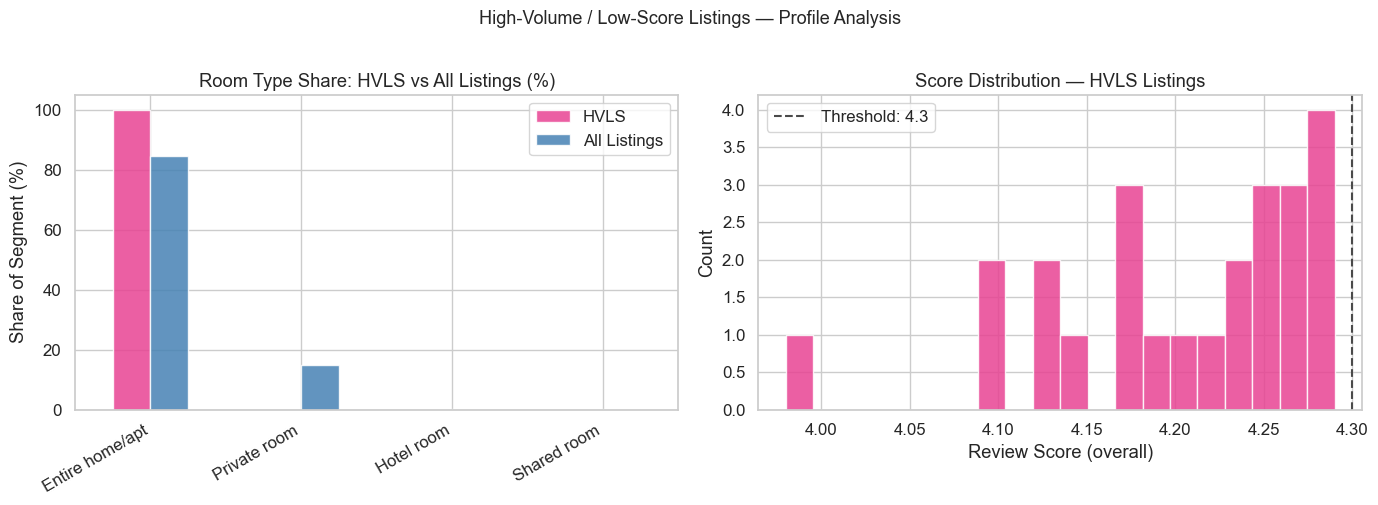

In [9]:
# Thresholds
HIGH_REVIEWS_THRESHOLD = df['number_of_reviews'].quantile(0.75)
LOW_SCORE_THRESHOLD    = 4.3   

df['is_high_vol_low_score'] = (
    (df['number_of_reviews'] >= HIGH_REVIEWS_THRESHOLD) &
    (df['review_scores_rating'] < LOW_SCORE_THRESHOLD)
)
plot_df['is_high_vol_low_score'] = df['is_high_vol_low_score']


hvls_plot   = plot_df[plot_df['is_high_vol_low_score'] == True]
others_plot = plot_df[plot_df['is_high_vol_low_score'] == False]

print(f'HVLS listings (review count >= {HIGH_REVIEWS_THRESHOLD:.0f} AND score < {LOW_SCORE_THRESHOLD}): '
      f'{len(hvls_plot):,} ({len(hvls_plot)/len(plot_df)*100:.1f}% of non-outlier listings)')


compare_cols = ['price_capped', 'accommodates', 'minimum_nights',
                'availability_365', 'calculated_host_listings_count']
present_cols = [c for c in compare_cols if c in plot_df.columns]

comparison = pd.DataFrame({
    'HVLS (median)'      : hvls_plot[present_cols].median(),
    'All Others (median)': others_plot[present_cols].median()
})
print('\nMedian profile comparison (outliers excluded):')
print(comparison.to_string())

# ── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))


hvls_room = hvls_plot['room_type'].value_counts(normalize=True) * 100
all_room  = plot_df['room_type'].value_counts(normalize=True) * 100
room_compare = (
    pd.DataFrame({'HVLS': hvls_room, 'All Listings': all_room})
    .fillna(0)
    .sort_values('All Listings', ascending=False)
)
room_compare.plot(kind='bar', ax=axes[0], color=[ACCENT, 'steelblue'], alpha=0.85)
axes[0].set_title('Room Type Share: HVLS vs All Listings (%)')
axes[0].set_ylabel('Share of Segment (%)')
axes[0].set_xlabel('')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
axes[0].legend()

# Score distribution for HVLS group
axes[1].hist(
    hvls_plot['review_scores_rating'].dropna(),
    bins=20, color=ACCENT, edgecolor='white', alpha=0.85
)
axes[1].axvline(LOW_SCORE_THRESHOLD, color=NEUTRAL, ls='--', lw=1.5,
                label=f'Threshold: {LOW_SCORE_THRESHOLD}')
axes[1].set_title('Score Distribution — HVLS Listings')
axes[1].set_xlabel('Review Score (overall)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('High-Volume / Low-Score Listings — Profile Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../../reports/figures/4_5_high_vol_low_score.png', dpi=150, bbox_inches='tight')
plt.show()

> **Business Interpretation: The "Tourist Trap" Anomaly**
> 
> * **The "Entire Home" Monopoly on Disappointment:** The left chart reveals a stark structural finding: 100% of the High-Volume/Low-Score (HVLS) listings fall into the "Entire home/apt" category. There are zero private, shared, or hotel rooms in this failing segment. This indicates that poor guest experiences are highly concentrated in whole-property rentals where the host is absent, leading to issues with cleanliness, maintenance, or misrepresentation that go unresolved during the stay.
> * **The Distribution of Failure:** The right-hand histogram shows that even within this "low score" segment, the ratings are clustered right up against the 4.3 threshold. Very few properties survive with a score below 4.10 while maintaining high volume. This proves that once a property drops below a 4.0, the market effectively kills its booking velocity. The HVLS group represents "tourist traps"—properties that look good enough online to secure bookings but systematically deliver a sub-par (4.1–4.2) physical experience.
> 
> **Strategic Takeaways:**
> 1. **For Trust & Safety Operations:** The QA and intervention teams do not need to spread their resources across all room types. To eliminate the highest-friction properties on the platform, they should exclusively audit "Entire home/apt" listings that maintain high booking velocity but hover in the 4.1 to 4.29 rating danger zone. 
> 2. **For Host Education:** Automated warnings should be triggered for absent hosts managing entire homes when their score dips below 4.5, warning them that they are approaching the structural "death zone" (sub-4.3) where long-term booking volume collapses.

---
## 9. Review Sub-Dimension Scores

Inside Airbnb includes six sub-dimension scores: cleanliness, accuracy, check-in, communication, location, and value. These allow us to identify **which quality dimension drives overall satisfaction** and where Cape Town hosts are strongest and weakest.

Listings with all sub-dimension scores: 18,005
(Missing sub-scores: 4,471 listings, 19.9% — unreviewed listings)


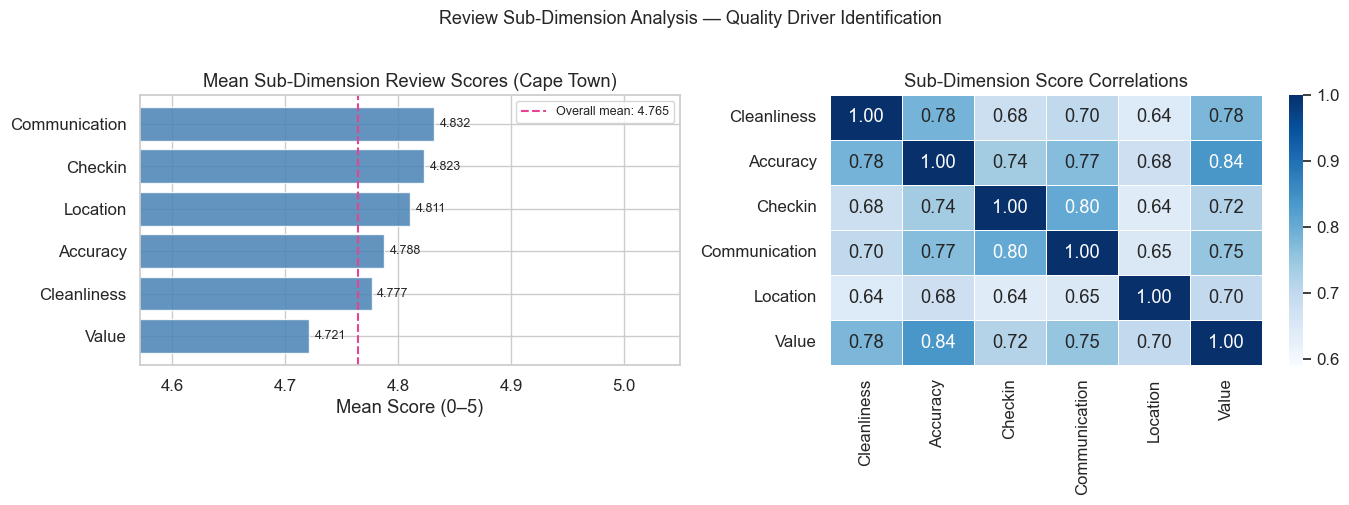


Mean sub-dimension scores (sorted highest to lowest):
Communication    4.832162
Checkin          4.823106
Location         4.811025
Accuracy         4.787535
Cleanliness      4.776583
Value            4.721384

Correlation of each sub-dimension with overall score:
Value            0.869411
Accuracy         0.858930
Cleanliness      0.822365
Communication    0.807638
Checkin          0.774965
Location         0.705854

Primary quality driver: Value (r = 0.869)


In [10]:
sub_score_cols = [
    'review_scores_cleanliness',
    'review_scores_accuracy',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value'
]
available_sub = [c for c in sub_score_cols if c in df.columns]

if not available_sub:
    print(
        'Sub-dimension score columns not found in the Gold layer.\n'
        'They may have been dropped during clean_listings() in src/clean.py.\n'
        'To fix: ensure these columns are retained in the Silver → Gold pipeline step.'
    )
else:
    sub_scores = df[available_sub + ['review_scores_rating']].dropna(subset=available_sub)
    short_labels = {c: c.replace('review_scores_', '').title() for c in available_sub}

    print(f'Listings with all sub-dimension scores: {len(sub_scores):,}')
    print(f'(Missing sub-scores: {len(df) - len(sub_scores):,} listings, '
          f'{(len(df) - len(sub_scores))/len(df)*100:.1f}% — unreviewed listings)')

    fig, axes = plt.subplots(1, 2, figsize=(FIG_W, 5))

    # ── Mean sub-dimension scores bar chart ──────────────────────────────────
    means = sub_scores[available_sub].mean().sort_values(ascending=True)
    labels = [short_labels[c] for c in means.index]

    axes[0].barh(labels, means.values, color='steelblue', alpha=0.85)
    axes[0].set_title('Mean Sub-Dimension Review Scores (Cape Town)')
    axes[0].set_xlabel('Mean Score (0–5)')

    
    xlim_min = max(3.0, means.min() - 0.15)
    axes[0].set_xlim(xlim_min, 5.05)

    for i, v in enumerate(means.values):
        axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

    # Overall score reference line
    overall_mean = sub_scores['review_scores_rating'].mean()
    axes[0].axvline(overall_mean, color=ACCENT, ls='--', lw=1.5,
                    label=f'Overall mean: {overall_mean:.3f}')
    axes[0].legend(fontsize=9)

    # ── Correlation heatmap ──────────────────────────────────────────────────
    corr_sub = sub_scores[available_sub].corr()
    corr_sub.index   = [short_labels[c] for c in corr_sub.index]
    corr_sub.columns = [short_labels[c] for c in corr_sub.columns]

    
    vmin_corr = max(0.0, corr_sub.values[corr_sub.values < 0.999].min() - 0.05)
    sns.heatmap(
        corr_sub, annot=True, fmt='.2f', cmap='Blues',
        linewidths=0.5, ax=axes[1],
        vmin=vmin_corr, vmax=1.0
    )
    axes[1].set_title('Sub-Dimension Score Correlations')

    plt.suptitle('Review Sub-Dimension Analysis — Quality Driver Identification', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('../../reports/figures/4_5_sub_dimension_scores.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nMean sub-dimension scores (sorted highest to lowest):')
    print(means.sort_values(ascending=False).rename(short_labels).to_string())

    
    if 'review_scores_rating' in sub_scores.columns:
        driver_corr = sub_scores[available_sub].corrwith(
            sub_scores['review_scores_rating']
        ).sort_values(ascending=False)
        driver_corr.index = [short_labels[c] for c in driver_corr.index]
        print('\nCorrelation of each sub-dimension with overall score:')
        print(driver_corr.to_string())
        print(f'\nPrimary quality driver: {driver_corr.index[0]} (r = {driver_corr.iloc[0]:.3f})')

> **Business Interpretation: Quality Drivers & The Expectation Gap**
> 
> * **The Core Driver (Value & Accuracy):** The data definitively proves what actually drives a 5-star overall review. "Value" has the absolute lowest average score across the city (4.721), yet it holds the highest correlation with the overall rating ($r = 0.869$). Combined with "Accuracy" ($r = 0.858$), this proves that guest satisfaction is dictated by the "Expectation Gap." If a guest feels the physical property perfectly matches the photos (Accuracy) and the price was fair for what they received (Value), they award a 5-star review regardless of the absolute luxury level.
> * **Operational Table Stakes:** Conversely, Communication and Check-in boast the highest average scores (4.83+) but have weaker correlations with the overall score. These are baseline operational "table stakes." Communicating well and providing an easy check-in are basic expectations; getting them right will not save a host's overall rating if the property itself is overpriced or misrepresented.
> * **The Location Myth:** Strikingly, Location has the weakest correlation ($r = 0.705$) with overall satisfaction. Because guests inherently know where the property is via the map before they book, geography is already priced into their decision. They do not heavily penalize or reward the host for location in the final post-stay rating.
> 
> **Strategic Takeaways:**
> 1. **For Host Education:** Hosts who obsess over sending overly communicative welcome messages are optimizing the wrong metric. Platform education teams should pivot their host-facing content to emphasize writing brutally honest, non-exaggerated listing descriptions (Accuracy) and pricing to market reality (Value), as these are the true mathematical drivers of long-term survival.
> 2. **For Ranking & Sorting Algorithms:** Because "Value" and "Accuracy" are the primary quality drivers, the search algorithm should dynamically boost listings that over-index specifically in these two sub-dimensions, rather than relying strictly on the aggregate overall score which is heavily inflated by the "Check-in" and "Communication" table stakes.